# Copy Number Correction, Raw Data

June 6, 2024

## Goal:
Apply the copy number correction to the raw data.

**Procedure:**
For each gene:
1. Retrieve replication timing
2. H from config, determine proportion of cells that have replicated for each timepoint.
3. Correct copy number based on this proportion.
4. Repeat 1-3 for all genes
5. Normalize each sample to equal counts.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [451]:
from src.CopyNumberCorrection import CopyNumberCorrector

corrector = CopyNumberCorrector()
corrector.compute_replication_timing()
corrector.correct_for_copy_number()

0/4835 - 00:00:00.002
1000/4835 - 00:00:00.709
2000/4835 - 00:00:01.400
3000/4835 - 00:00:02.107
4000/4835 - 00:00:02.794


In [489]:
corrector.compute_ptrs()

(0.99, 1.2)

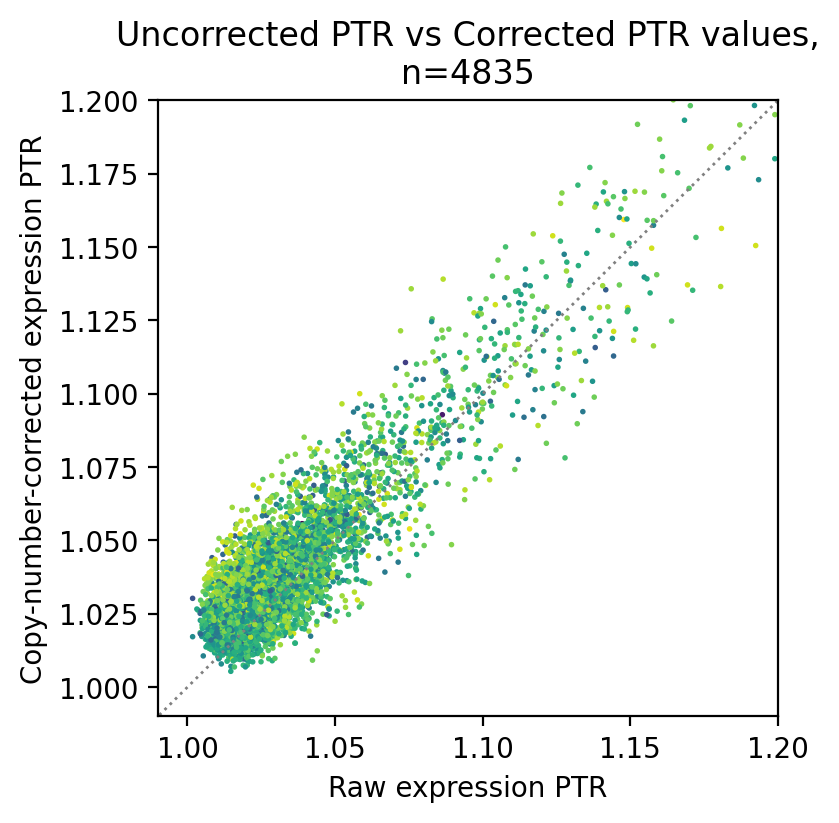

In [493]:
corrector.plot_ptrs()
plt.plot([0, 2], [0, 2], lw=1, ls='dotted', c='gray')
plt.xlim(0.99, 1.2)
plt.ylim(0.99, 1.2)

In [ ]:
dat = corrector.ge_comparison_ptr_df
dat.sort_values('difference').head()

In [ ]:
0

(0.0, 12.0)

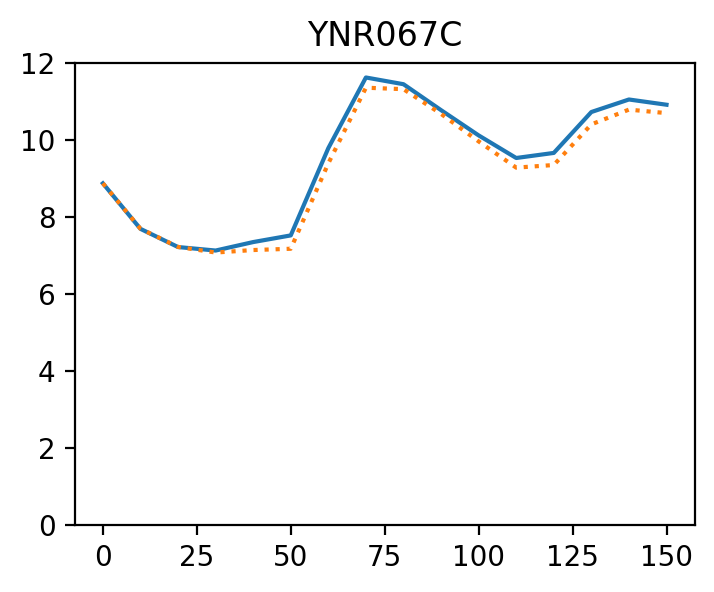

In [517]:
# A gene that stabilizes following copy number correction
corrector.plot_corrected_gene('YNR067C')
plt.ylim(0, 12)

(0.0, 12.0)

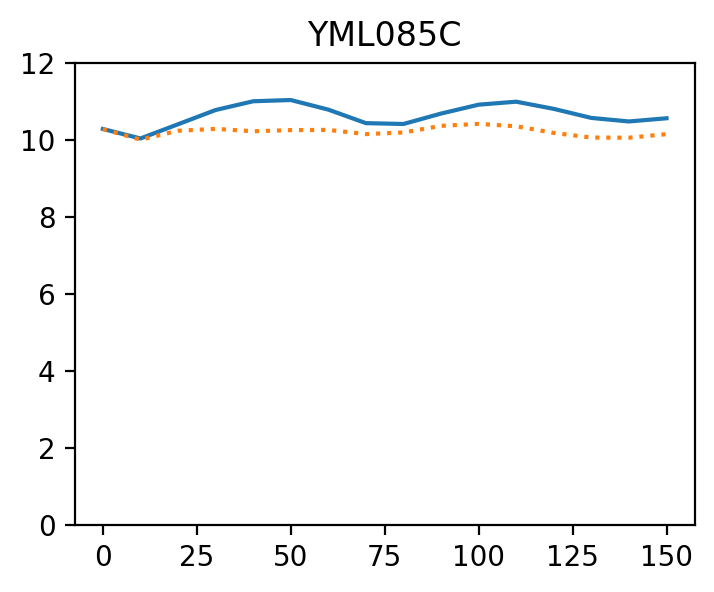

In [509]:
# A gene that stabilizes following copy number correction
corrector.plot_corrected_gene('YML085C')
plt.ylim(0, 12)

(0.0, 12.0)

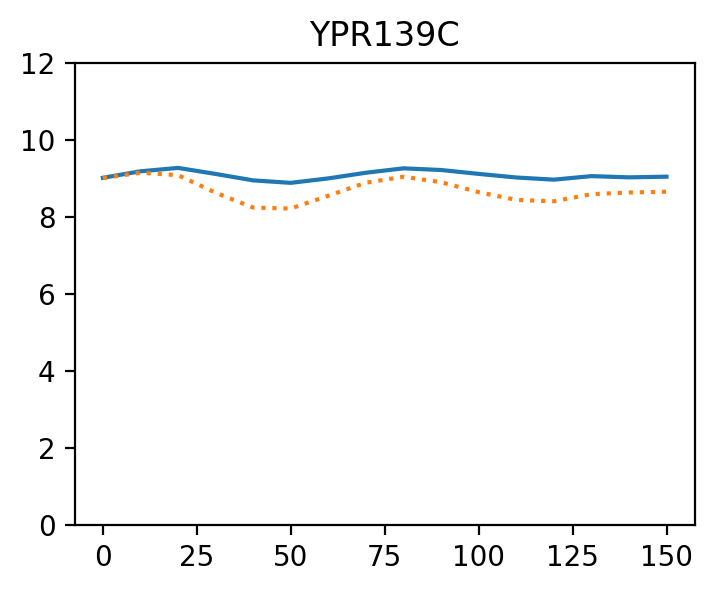

In [510]:
# A gene that cycles following copy number correction
corrector.plot_corrected_gene('YPR139C')
plt.ylim(0, 12)

In [ ]:
# Good examples of how copy number effects, how to proceed?
# Quantify the set of each: low to high and high to low PTR
# what story that tells.

# How will the chromatin tie in?

# Note
# -- eliminate the RG1 timepoints

# Story:
#
# 1. Copy number correction is needed because without it we are not taking into account ___.
#    - Here are a handful of genes whose story changes because of the copy number correction
#
#
# 2. We are correcting the copy number properly because we have replication timing
#    that is concordant with existing studies and is produced from our data alone.
#    - Supporting logic for how we did the copy number correction.
#          - Simple and straightforward method.
#
